# Method:



In [1]:
import sys
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import deepchem as dc

import tensorflow as tf
import os
import sys
import rdkit
import h5py
import helper_functions as h

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.tri
import rdkit.Chem
import rdkit.Chem.AllChem as Chem
import rdkit.Chem.AllChem as AllChem
from rdkit.Chem import Descriptors
from rdkit.Chem import rdMolDescriptors
import mpl_toolkits.mplot3d
from sklearn.ensemble import RandomForestRegressor
from sklearn.decomposition import PCA
from collections import Counter

print("TensorFlow version: " + tf.__version__)

# topology stuff
from gtda.plotting import plot_point_cloud
from gtda.homology import VietorisRipsPersistence
from gtda.plotting import plot_diagram
from gtda.diagrams import PersistenceEntropy
from gtda.diagrams import NumberOfPoints
from gtda.diagrams import Amplitude
from sklearn.pipeline import make_union, Pipeline

# fixc this at some point
sys.path.append(r"C:\Users\ella_\Documents\GitHub\graphs_and_topology_for_chemistry")
sys.path.append(r"C:\Users\ella_\Documents\GitHub\icosahedron_projection")

import projection
from projection.molecule import Molecule
from projection.pdbmolecule import PDBMolecule
from projection.mol2molecule import Mol2Molecule

import helper_functions as h
#from projection.face import Face

# $UN THIS
save_dir=r'F:\Nextcloud\science\Datasets\converted_pdbbind\v2015'
data_dir=r'F:\Nextcloud\science\Datasets'
results_dir=r"F:\Nextcloud\science\results\topology_and_graphs\PDBBind"
test_file='gdb7.sdf'
test_file_ligand='1a1c_ligand.mol2'
test_pdb_code='1a1c'
out_file_name='PDBBind_refined_topological_features.hdf5'
make_dataset=False # whether to recalc the dataset

name_file_name="INDEX_core_name.2013",
data_file_name="INDEX_core_data.2013",
cluster_file_name = "INDEX_core_cluster.2013"
dc.__version__
data_file_location = os.path.join(data_dir, test_file)

TensorFlow version: 2.3.0


In [2]:
import scipy.io

mat = scipy.io.loadmat(data_file_location)

ValueError: Unknown mat file type, version 32, 32

In [1]:
from rdkit.Chem import PandasTools
import pandas as pd
import os
from rdkit import RDConfig

In [12]:
#sdfFile = os.path.join(RDConfig.RDDataDir,'NCI/first_200.props.sdf')
frame = PandasTools.LoadSDF(data_file_location,smilesName='SMILES',molColName='Molecule',
           includeFingerprints=True, removeHs=False, strictParsing=True)

,ID,SMILES,Molecule
0,gdb7k_0000.xyz,[H].[H].[H][C][H],
1,gdb7k_0001.xyz,[H]C([H])([H])C([H])([H])[H],
2,gdb7k_0002.xyz,[H]C([H])=C([H])[H],
3,gdb7k_0003.xyz,[H]C#C[H],
4,gdb7k_0004.xyz,[H]OC([H])([H])C([H])([H])[H],

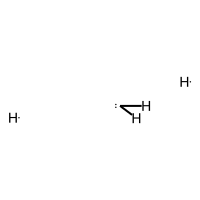
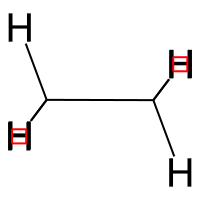
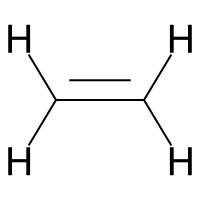
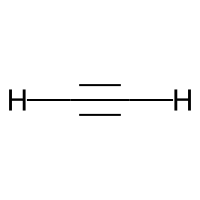
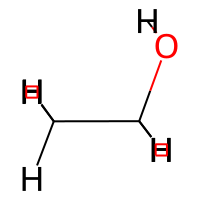

In [14]:
frame2 = PandasTools.LoadSDF(data_file_location)

,ID,ROMol
0,gdb7k_0000.xyz,
1,gdb7k_0001.xyz,
2,gdb7k_0002.xyz,
3,gdb7k_0003.xyz,
4,gdb7k_0004.xyz,

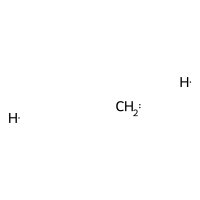
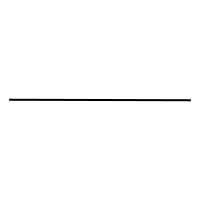
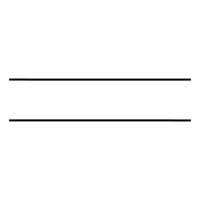
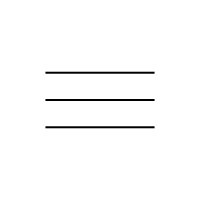
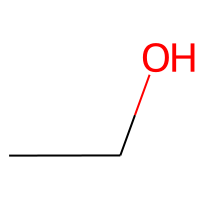

In [15]:
frame2.head()

# Control using MoleculeNet Methods

## Multiple Regression Model

In [12]:
tasks, datasets, transformers = dc.molnet.load_qm8(
    shard_size=2000, featurizer="ECFP", split="random")

'split' is deprecated.  Use 'splitter' instead.


In [16]:
train_dataset, valid_dataset, test_dataset = datasets
len(tasks)
f'Compound train/valid/test split: {len(train_dataset)}/{len(valid_dataset)}/{len(test_dataset)}'

'Compound train/valid/test split: 17397/2175/2175'

In [36]:
train_dataset.X

array([<deepchem.feat.mol_graphs.ConvMol object at 0x00000291E69DC388>,
       ...,
      dtype=object)

In [17]:
# We want to know the RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)

In [18]:
n_layers = 3
model = dc.models.MultitaskRegressor(
    len(chembl_tasks),
    n_features=1024,
    layer_sizes=[1000] * n_layers,
    dropouts=[.25] * n_layers,
    weight_init_stddevs=[.02] * n_layers,
    bias_init_consts=[1.] * n_layers,
    learning_rate=.0003,
    weight_decay_penalty=.0001,
    batch_size=100)

In [19]:
model.fit(train_dataset, nb_epoch=5)

0.9832200186593192

In [28]:
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00
valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00
print(valid_scores)
test_scores = model.evaluate(test_dataset, [avg_rms], transformers)
assert test_scores['mean-rms_score'] < 10.00
print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

{'mean-rms_score': 0.053393667960364766}
Train scores average = {'mean-rms_score': 0.05217953456918096}
Validate scores average = {'mean-rms_score': 0.053393667960364766}
Test scores average = {'mean-rms_score': 0.053142261765162624}


## Graph Conv on QM8

In [29]:
tasks, datasets, transformers = dc.molnet.load_qm8(
   shard_size=2000, featurizer="GraphConv", split="random")
train_dataset, valid_dataset, test_dataset = datasets
# RMS, averaged across tasks
avg_rms = dc.metrics.Metric(dc.metrics.rms_score, np.mean)
model = dc.models.GraphConvModel(
   len(chembl_tasks), batch_size=128, mode='regression')
# Fit trained model
model.fit(train_dataset, nb_epoch=5)
# We now evaluate our fitted model on our training and validation sets
train_scores = model.evaluate(train_dataset, [avg_rms], transformers)
assert train_scores['mean-rms_score'] < 10.00

valid_scores = model.evaluate(valid_dataset, [avg_rms], transformers)
assert valid_scores['mean-rms_score'] < 10.00

print(f"Train scores average = {train_scores}")
print(f"Validate scores average = {valid_scores}")
print(f"Test scores average = {test_scores}")

'split' is deprecated.  Use 'splitter' instead.
C:\Users\ella_\.conda\envs\graphs-and-topology-for-chemists\lib\site-packages\tensorflow\python\framework\indexed_slices.py:432: UserWarning: Converting sparse IndexedSlices to a dense Tensor of unknown shape. This may consume a large amount of memory.
  "Converting sparse IndexedSlices to a dense Tensor of unknown shape. "


Train scores average = {'mean-rms_score': 0.052558182536062294}
Validate scores average = {'mean-rms_score': 0.05373292468375723}
Test scores average = {'mean-rms_score': 0.053142261765162624}
